# Unit 3 Final Project

Before you get started on your project, take a moment to review how you can make requests from the following APIs:
- **ESPN**
- **X**
- **Spotify**

First, you will need to set up your API credentials:
   - **Spotify**: `SPOTIFY_CLIENT_ID` and `SPOTIFY_CLIENT_SECRET` from https://developer.spotify.com/dashboard
   - **X (Twitter)**: `X_BEARER_TOKEN` from https://developer.twitter.com/en/portal/dashboard
   - **ESPN**: No authentication required!

In [2]:
# Import required libraries
import requests
import json
import random
import asyncio
import os

## 1. Spotify API - Random Song

In [ ]:
# Setup API authorization before making request
SPOTIFY_CLIENT_ID = "ADD YOUR ID HERE"
SPOTIFY_CLIENT_SECRET = "ADD YOUR SECRET HERE"

# Get access token
auth_response = requests.post('https://accounts.spotify.com/api/token', {
    'grant_type': 'client_credentials',
    'client_id': SPOTIFY_CLIENT_ID,
    'client_secret': SPOTIFY_CLIENT_SECRET,
})

auth_data = auth_response.json()
access_token = auth_data['access_token']

headers = {
    'Authorization': f'Bearer {access_token}'
}

In [25]:
# Search for a random popular track
search_query = random.choice(['pop', 'rock', 'hip hop', 'jazz', 'electronic'])
spotify_response = requests.get(
    'https://api.spotify.com/v1/search',
    headers=headers,
    params={'q': search_query, 'type': 'track', 'limit': 50}
)

print(spotify_response)
spotify_data = spotify_response.json()
print(spotify_data['tracks']['items'][0]['artists'][0]['name'])
print(spotify_data['tracks']['items'][0]['name'])

<Response [200]>
Brenda Lee
Rockin' Around The Christmas Tree


## 2. X (Twitter) API - Random Recent Post

In [27]:
# Setup API authorization before making request

X_BEARER_TOKEN = "ADD YOUR BEARER TOKEN HERE"

headers = {
    'Authorization': f'Bearer {X_BEARER_TOKEN}'
}

In [28]:
# Search for recent tweets about a random topic
search_topic = random.choice(['sports', 'technology', 'music', 'news', 'science'])
x_response = requests.get(
    'https://api.twitter.com/2/tweets/search/recent',
    headers=headers,
    params={
        'query': f'{search_topic} -is:retweet lang:en',
        'max_results': 10,
        'tweet.fields': 'created_at,public_metrics,author_id'
    }
)

x_data = x_response.json()
if 'data' in x_data and x_data['data']:
    random_tweet = random.choice(x_data['data'])
    print(f"\nRandom Tweet Found (Topic: {search_topic}):")
    print(f"  Text: {random_tweet['text'][:200]}...")
    if 'public_metrics' in random_tweet:
        print(f"  Likes: {random_tweet['public_metrics'].get('like_count', 0)}")
        print(f"  Retweets: {random_tweet['public_metrics'].get('retweet_count', 0)}")


Random Tweet Found (Topic: sports):
  Text: After dropping to No. 7 in the latest CFP rankings, Texas A&amp;M HC Mike Elko is asking for more clarity regarding the Aggies' surprising drop. https://t.co/o3GVk8ljpQ...
  Likes: 0
  Retweets: 0


## 3. ESPN API (Hidden) - Random Basketball Game

*Note, this API will most likely only work when using a local version of Jupyter Notebooks because the cloud permission settings appear to block ESPN.*

In [3]:
espn_response = requests.get(
    'http://site.api.espn.com/apis/site/v2/sports/basketball/nba/scoreboard'
)

espn_data = espn_response.json()
espn_data

{'leagues': [{'id': '46',
   'uid': 's:40~l:46',
   'name': 'National Basketball Association',
   'abbreviation': 'NBA',
   'slug': 'nba',
   'season': {'year': 2026,
    'startDate': '2025-10-01T07:00Z',
    'endDate': '2026-06-27T06:59Z',
    'displayName': '2025-26',
    'type': {'id': '2',
     'type': 2,
     'name': 'Regular Season',
     'abbreviation': 'reg'}},
   'logos': [{'href': 'https://a.espncdn.com/i/teamlogos/leagues/500/nba.png',
     'width': 500,
     'height': 500,
     'alt': '',
     'rel': ['full', 'default'],
     'lastUpdated': '2018-06-05T12:07Z'},
    {'href': 'https://a.espncdn.com/combiner/i?img=/i/teamlogos/leagues/500-dark/nba.png&w=500&h=500&transparent=true',
     'width': 500,
     'height': 500,
     'alt': '',
     'rel': ['full', 'dark'],
     'lastUpdated': '2025-12-02T23:30Z'}],
   'calendarType': 'day',
   'calendarIsWhitelist': True,
   'calendarStartDate': '2025-10-01T07:00Z',
   'calendarEndDate': '2026-06-27T06:59Z',
   'calendar': ['2025-10-

### 🚀 YOUR TURN! Design Your Own Study
Now it's time to use one of the APIs above to collect real data and answer your own question!

Instructions:
- **My Question:** Write a clear research question that requires concepts covered in Unit 3 to analyze.
- **My Study:** State the API you will be using. Then, describe how much data you will randomly collect from the API.
- **My Analysis:** Perform the analysis you need. Remember, a level 4 requires 3 different techniques to be included in your analysis.
- **My Answer:** Interpret your results. Tell me what I should conclude from the specific visualizations you make and the specific values you find.

# 📝 My Question

How does the mean Spotify popularity score differ across five music genres (pop, rock, hip hop, jazz, and electronic), and are some genres consistently more popular than others based on Spotify’s popularity metric?

# 📊 My Study

*Describe your study design:*
I am using the Spotify API to measure the variables popularity score (0-100 scale), track name length, and the genre of the tracks. The sample size is 50 tracks per genre (5 genres) which is 250 tracks total. The genres I am studying are pop, rock, hip hop, jazz, and electronic. I will collect my data by using Spotify's search results for each genre and collecting the data needed to conduct the study. A possible bias is that Spotify's search results tend to favor popular songs which means that the sample may overrepresent popular music and underrepresent less popular songs. 

The Margin of error formula is ME = t (s/sqrt(n)). Since popularity ranges from 0-100 a good estimate for the standard deviation is 20. I will use a 90 percent confidence level (t = 1.65), and a sample size of 50. Me = 1.65(20/sqrt(50)) is approximately 4.7, which is less than 10. 

# 🔬 My Analysis


=== Descriptive Statistics by Genre ===
            count   mean        std   min    25%   50%    75%    max
genre                                                               
electronic   50.0  52.68  25.601690   7.0  33.25  48.5  79.75   86.0
hip hop      50.0  59.64  22.718113  28.0  37.00  56.5  83.00   89.0
jazz         50.0  41.42  27.075171   9.0  18.00  29.0  72.25   86.0
pop          50.0  73.82  15.810988  44.0  60.00  72.0  90.75  100.0
rock         50.0  71.48  13.468391  30.0  65.00  71.0  81.50   95.0


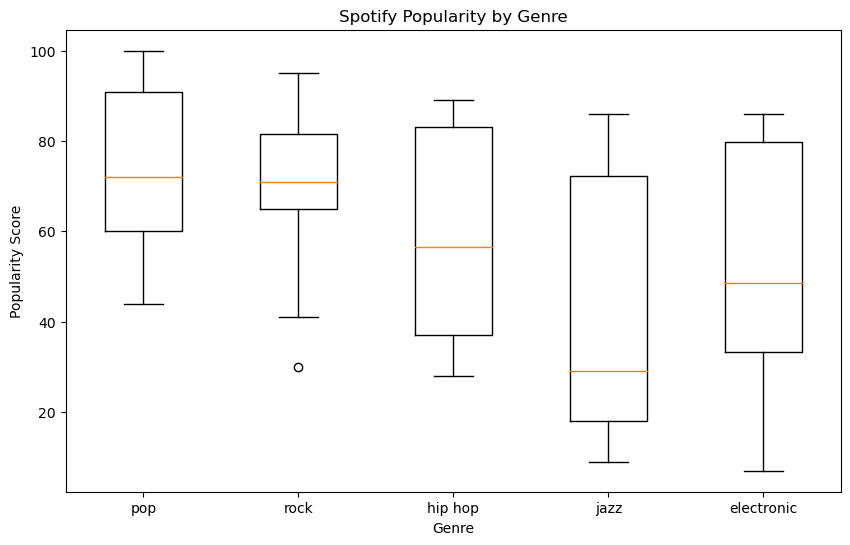

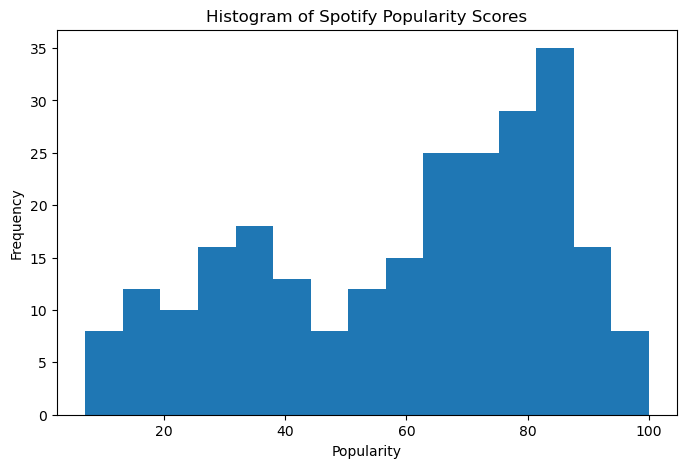


=== 90% Confidence Intervals and Margin of Error ===
pop:
 Mean = 73.82
 Standard Error = 2.24
 Margin of Error = 3.75
 90% CI = (70.07, 77.57)

rock:
 Mean = 71.48
 Standard Error = 1.90
 Margin of Error = 3.19
 90% CI = (68.29, 74.67)

hip hop:
 Mean = 59.64
 Standard Error = 3.21
 Margin of Error = 5.39
 90% CI = (54.25, 65.03)

jazz:
 Mean = 41.42
 Standard Error = 3.83
 Margin of Error = 6.42
 90% CI = (35.00, 47.84)

electronic:
 Mean = 52.68
 Standard Error = 3.62
 Margin of Error = 6.07
 90% CI = (46.61, 58.75)

Correlation between track name length and popularity: 0.219


In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import math
from scipy import stats

# =========================
# Spotify API Credentials
# =========================
SPOTIFY_CLIENT_ID = "c35a78f979e14baeb4704b1e682750af"
SPOTIFY_CLIENT_SECRET = "67c4b7088e334e9c893a893cbb0e35c5"

# =========================
# Get Access Token
# =========================
def get_access_token(client_id, client_secret):
    response = requests.post(
        "https://accounts.spotify.com/api/token",
        data={
            "grant_type": "client_credentials",
            "client_id": client_id,
            "client_secret": client_secret
        }
    )
    response.raise_for_status()
    return response.json()["access_token"]

access_token = get_access_token(SPOTIFY_CLIENT_ID, SPOTIFY_CLIENT_SECRET)
headers = {"Authorization": f"Bearer {access_token}"}

# =========================
# Collect Data
# =========================
genres = ["pop", "rock", "hip hop", "jazz", "electronic"]
tracks_per_genre = 50
tracks_data = []

for genre in genres:
    print(f"Collecting tracks for genre: {genre}")
    
    response = requests.get(
        "https://api.spotify.com/v1/search",
        headers=headers,
        params={
            "q": genre,
            "type": "track",
            "limit": tracks_per_genre
        }
    )
    
    if response.status_code != 200:
        print(f"Failed to collect data for {genre}")
        continue
    
    tracks = response.json()["tracks"]["items"]
    
    for track in tracks:
        tracks_data.append({
            "genre": genre,
            "track_name": track["name"],
            "popularity": track["popularity"],
            "track_name_length": len(track["name"])
        })
    
    time.sleep(1)  # avoid rate limits

df = pd.DataFrame(tracks_data)

# =========================
# Descriptive Statistics
# =========================
print("\n=== Descriptive Statistics by Genre ===")
print(df.groupby("genre")["popularity"].describe())

# =========================
# Boxplot (Graphical Analysis)
# =========================
plt.figure(figsize=(10,6))
plt.boxplot(
    [df[df["genre"] == g]["popularity"] for g in genres],
    labels=genres
)
plt.title("Spotify Popularity by Genre")
plt.xlabel("Genre")
plt.ylabel("Popularity Score")
plt.show()

# =========================
# Histogram (CLT / Normality)
# =========================
plt.figure(figsize=(8,5))
plt.hist(df["popularity"], bins=15)
plt.title("Histogram of Spotify Popularity Scores")
plt.xlabel("Popularity")
plt.ylabel("Frequency")
plt.show()

# =========================
# Confidence Intervals + Margin of Error (90%)
# =========================
print("\n=== 90% Confidence Intervals and Margin of Error ===")

for genre in genres:
    sample = df[df["genre"] == genre]["popularity"]
    n = len(sample)
    mean = sample.mean()
    std = sample.std(ddof=1)
    se = std / math.sqrt(n)
    t_crit = stats.t.ppf(0.95, df=n-1)  # 90% CI
    me = t_crit * se
    lower = mean - me
    upper = mean + me
    
    print(f"{genre}:")
    print(f" Mean = {mean:.2f}")
    print(f" Standard Error = {se:.2f}")
    print(f" Margin of Error = {me:.2f}")
    print(f" 90% CI = ({lower:.2f}, {upper:.2f})\n")

# =========================
# Correlation Analysis
# =========================
correlation = df["track_name_length"].corr(df["popularity"])
print("Correlation between track name length and popularity:", round(correlation, 3))

# ✅ My Answer

The results show clear differences in mean between Spotify popularity across genres. For pop, the mean was 73.82 with a 90% CI: (70.07-77.57) and Rock has a mean of 71.48 with a 90% CI: (68.29-74.67), these are the genres with the highest average popularity, while jazz has the lowest mean (41.42, 90% CI: (35.00-47.84)).Hip Hop (mean = 59.64 ) and electronic (mean = 52.68) fall in between. 

The confidence intervals for pop and rock overlap, which means that have similar popularity, while Jazz has the lowest mean, which suggests that it is significantly less popular.

The correlation between track name length and popularity is weak. It has an r value of 0.219), which means there is little to no relationship between these two variables. A limitation of the study is that Spotify search results favor more popular songs, meaning that this study may not represent all songs from each genre, but the most popular ones. 